In [4]:
import os
print(os.getcwd())

C:\Users\HP\TruthLens\eda


In [6]:
import pandas as pd

df = pd.read_csv("../dataset/final_dataset.csv")

## Dataset Overview

In [9]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df["label"].value_counts())

Shape: (23196, 5)

Columns:
['id', 'news_url', 'title', 'tweet_ids', 'label']

Missing Values:
id              0
news_url      330
title           0
tweet_ids    1501
label           0
dtype: int64

Label Distribution:
label
1    17441
0     5755
Name: count, dtype: int64


## Class Distribution

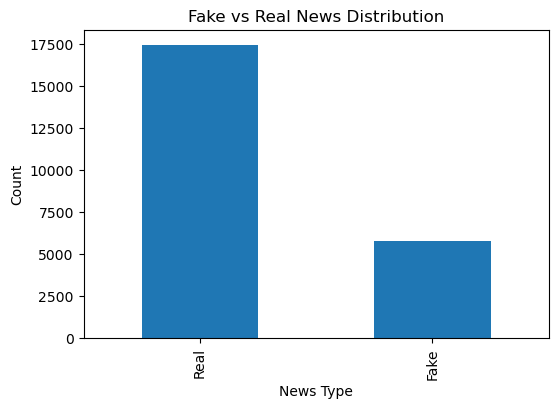

In [10]:
import matplotlib.pyplot as plt

label_names = {
    0: "Fake",
    1: "Real"
}

counts = df["label"].map(label_names).value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")

plt.title("Fake vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Count")

plt.show()

## Title Length Analysis

count    23196.000000
mean        68.303328
std         23.287987
min         10.000000
25%         55.000000
50%         68.000000
75%         84.000000
max        340.000000
Name: title_length, dtype: float64


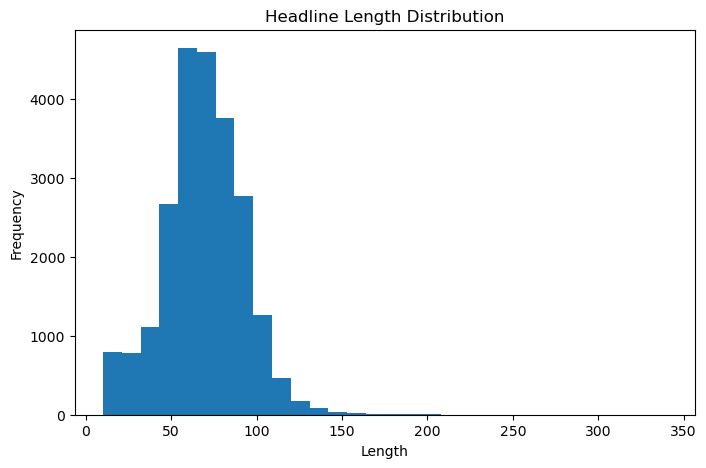

In [12]:
df["title_length"] = df["title"].astype(str).apply(len)

print(df["title_length"].describe())


plt.figure(figsize=(8,5))

plt.hist(df["title_length"], bins=30)

plt.title("Headline Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## Word Count Analysis & Distribution

count    23196.000000
mean        11.161192
std          3.977693
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         53.000000
Name: word_count, dtype: float64


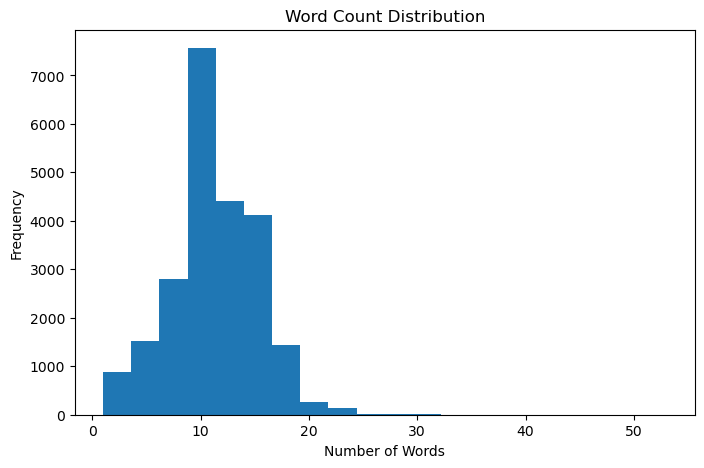

In [13]:
df["word_count"] = df["title"].astype(str).apply(
    lambda x: len(x.split())
)

print(df["word_count"].describe())


plt.figure(figsize=(8,5))

plt.hist(df["word_count"], bins=20)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## Word Cloud

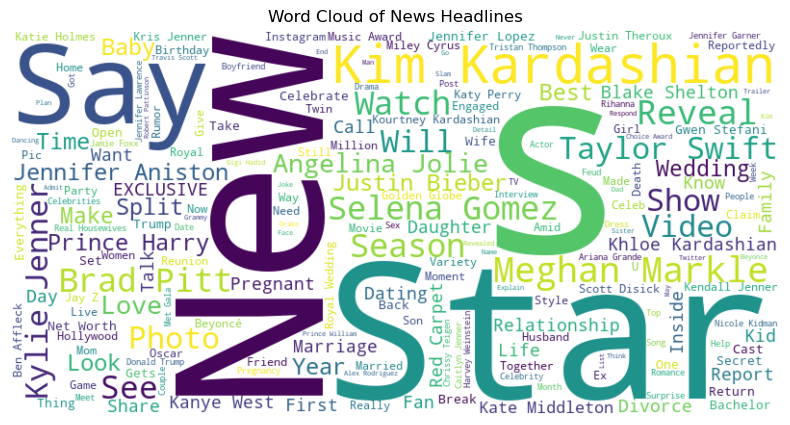

In [14]:
from wordcloud import WordCloud

text = " ".join(df["title"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of News Headlines")
plt.show()

## Top Words

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["title"])

word_counts = X.toarray().sum(axis=0)

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    "word": words,
    "count": word_counts
})

top_words = word_freq.sort_values(
    by="count",
    ascending=False
).head(20)

print(top_words)

             word  count
8411   kardashian   1172
10564         new   1068
8190     jennifer    800
8185       jenner    775
139          2018    766
1346         baby    728
8577          kim    722
16803     wedding    679
14687        star    656
13623      season    648
13472        says    638
1311       awards    634
9819       meghan    594
8364       justin    587
11990      prince    559
9593       markle    525
2151         brad    478
12918     reveals    475
7101        harry    463
13669      selena    457


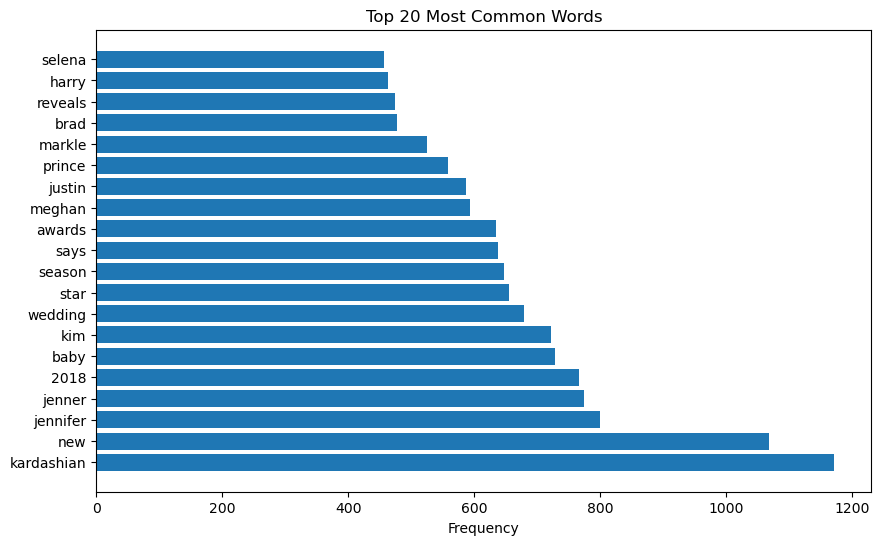

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    top_words["word"],
    top_words["count"]
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12112\3657718256.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


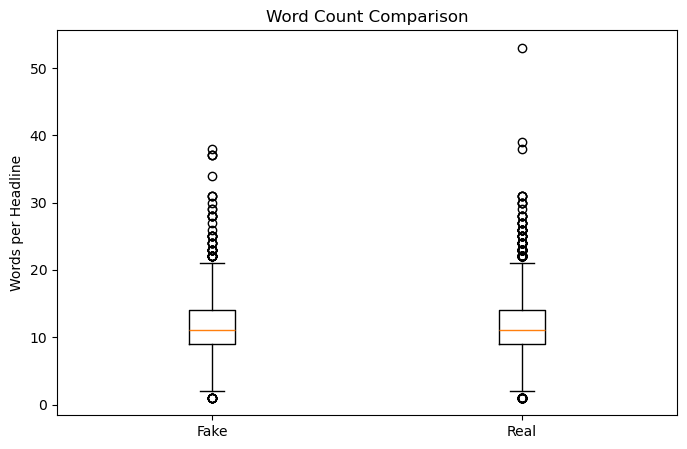

In [17]:
fake_titles = df[df["label"] == 0]["word_count"]
real_titles = df[df["label"] == 1]["word_count"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [fake_titles, real_titles],
    labels=["Fake", "Real"]
)

plt.title("Word Count Comparison")
plt.ylabel("Words per Headline")

plt.show()